In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats

# Load cleaned data
new_products = pd.read_csv("/Users/wengel/230A_final_project/code/new_products.csv")
new_products.shape

(5056, 35)

In [2]:
m4 = smf.ols(
    """log_price ~ C(primary_category, Treatment('Skincare'))
                + sephora_exclusive + limited_edition + online_only + new
                + size_ml + size_count
                + has_retinol + has_niacinamide + has_hyaluronic
                + has_vitamin_c + has_aha_bha + has_peptides
                + has_spf + has_fragrance + has_ceramides + has_vitamin_e""",
    data=new_products
).fit(cov_type="HC2")

print(m4.summary())



                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     88.86
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        00:55:39   Log-Likelihood:                -4547.1
No. Observations:                5056   AIC:                             9138.
Df Residuals:                    5034   BIC:                             9282.
Df Model:                          21                                         
Covariance Type:                  HC2                                         
                                                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

In [3]:
# Create interaction flag
new_products['is_fragrance_or_hair'] = new_products['primary_category'].isin(['Fragrance', 'Hair']).astype(int)

# Model 5
m5 = smf.ols(
    """log_price ~ C(primary_category, Treatment('Skincare'))
                + sephora_exclusive + limited_edition + online_only + new
                + size_ml + size_count
                + has_retinol + has_niacinamide + has_hyaluronic
                + has_vitamin_c + has_aha_bha + has_peptides
                + has_spf + has_fragrance + has_ceramides + has_vitamin_e
                + has_fragrance:is_fragrance_or_hair""",
    data=new_products
).fit(cov_type="HC2")

print(m5.summary())


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                     87.45
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        00:55:42   Log-Likelihood:                -4531.7
No. Observations:                5056   AIC:                             9109.
Df Residuals:                    5033   BIC:                             9260.
Df Model:                          22                                         
Covariance Type:                  HC2                                         
                                                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

In [4]:
#model 6 size interaction with category
m6 = smf.ols(
    """log_price ~ C(primary_category, Treatment('Skincare'))
                + sephora_exclusive + limited_edition + online_only + new
                + size_ml + size_count
                + has_retinol + has_niacinamide + has_hyaluronic
                + has_vitamin_c + has_aha_bha + has_peptides
                + has_spf + has_fragrance + has_ceramides + has_vitamin_e
                + size_ml:C(primary_category, Treatment('Skincare'))""",
    data=new_products
).fit(cov_type="HC2")

print(m6.summary())


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.259
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     73.16
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        00:55:47   Log-Likelihood:                -4545.0
No. Observations:                5056   AIC:                             9144.
Df Residuals:                    5029   BIC:                             9320.
Df Model:                          26                                         
Covariance Type:                  HC2                                         
                                                                        coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

In [9]:
#m6.params.filter(like="size_ml")
m6.pvalues.filter(like="size_ml")

size_ml                                                              0.619552
size_ml:C(primary_category, Treatment('Skincare'))[T.Bath & Body]    0.625691
size_ml:C(primary_category, Treatment('Skincare'))[T.Fragrance]      0.296130
size_ml:C(primary_category, Treatment('Skincare'))[T.Hair]           0.095456
size_ml:C(primary_category, Treatment('Skincare'))[T.Makeup]         0.088071
size_ml:C(primary_category, Treatment('Skincare'))[T.Other]          0.696860
dtype: float64

size ml as a predciotr isnot significant. It also does affect the categories. We can conclude it isn't statistically significant

In [10]:
m4params = m4.params
m4pvalues = m4.pvalues

terms = ['has_retinol', 'has_niacinamide', 'has_hyaluronic',
         'has_vitamin_c', 'has_aha_bha', 'has_peptides',
         'has_spf', 'has_fragrance', 'has_ceramides', 'has_vitamin_e']

for term in terms:
    if term in m4params:
        print(f"{term}: coef={m4params[term]:.4f}, p={m4pvalues[term]:.4f}")

has_retinol: coef=0.3483, p=0.0000
has_niacinamide: coef=0.1053, p=0.0014
has_hyaluronic: coef=0.0919, p=0.0001
has_vitamin_c: coef=0.1251, p=0.0000
has_aha_bha: coef=-0.0113, p=0.5716
has_peptides: coef=0.2004, p=0.0000
has_spf: coef=0.0944, p=0.0000
has_fragrance: coef=0.1149, p=0.0000
has_ceramides: coef=0.0454, p=0.2698
has_vitamin_e: coef=0.1011, p=0.0000


## M4 Model Summary — Key Observations

**Significant predictors (p < 0.05):**
- All primary categories are significant relative to Skincare baseline
- Fragrance is the most expensive category — associated with higher prices than Skincare
- `Bath & Body`, `Hair`, `Makeup`, and `Other` are all cheaper than Skincare
- `sephora_exclusive` is negative and significant : exclusive products are surprisingly associated with *lower* prices
- `size_ml` is positive and significant — larger products cost more as expected

**Non-significant predictors (p > 0.05):**
- `limited_edition`, `online_only`, and `new` — none of these marketing flags significantly affect price

**sephora_exclusive:**
The negative coefficient is counterintuitive and worth investigating further in diagnostics — could be driven by influential points or a specific category pulling the estimate down.


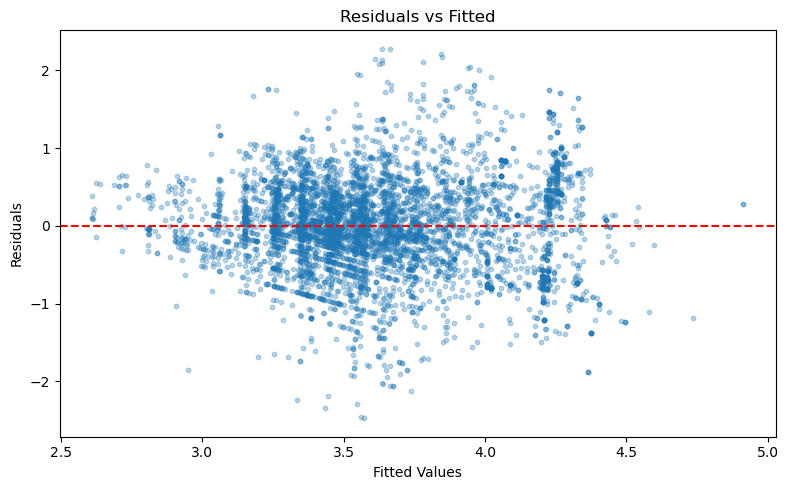

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(m4.fittedvalues, m4.resid, alpha=0.3, s=10)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

## Residuals vs Fitted
**Linearity** Residuals appear randomly scattered around zero , linearity assumption is reasonably met. 
However, there is a slight fan shape,  mild **heteroscedasticity** (unequal variance), which justifies the use of (HC2/HC3).

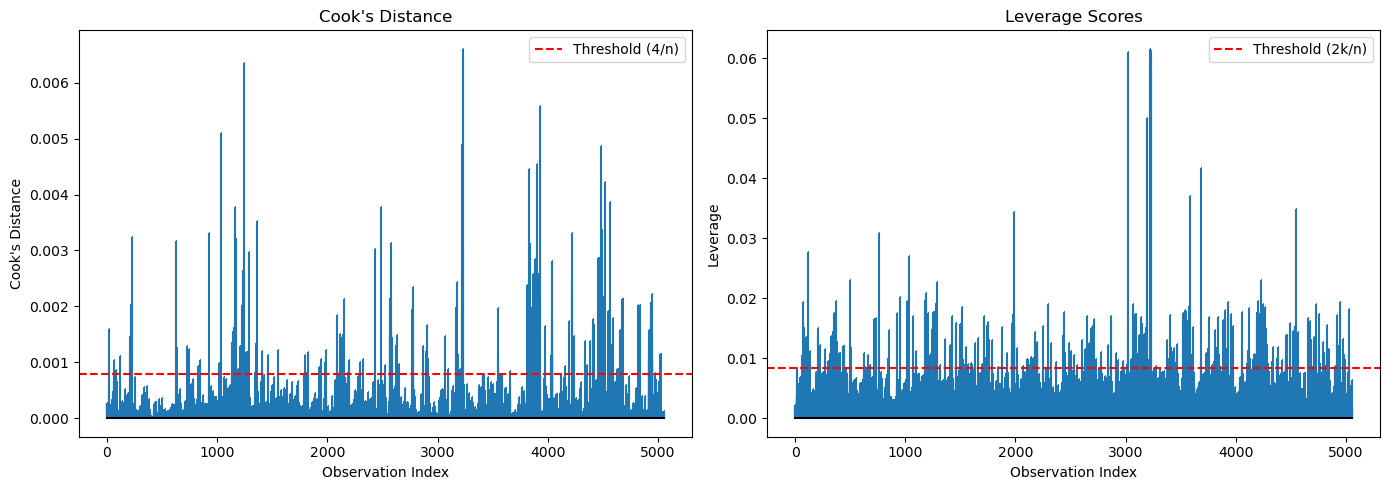

In [7]:
from statsmodels.stats.outliers_influence import OLSInfluence

influence = OLSInfluence(m4)
cooks_d = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cook's Distance
axes[0].stem(range(len(cooks_d)), cooks_d, markerfmt=",", linefmt="C0-", basefmt="k-")
axes[0].axhline(4/len(cooks_d), color='red', linestyle='--', label=f"Threshold (4/n)")
axes[0].set_xlabel("Observation Index")
axes[0].set_ylabel("Cook's Distance")
axes[0].set_title("Cook's Distance")
axes[0].legend()

# Leverage
axes[1].stem(range(len(leverage)), leverage, markerfmt=",", linefmt="C0-", basefmt="k-")
axes[1].axhline(2 * m4.df_model / len(leverage), color='red', linestyle='--', label="Threshold (2k/n)")
axes[1].set_xlabel("Observation Index")
axes[1].set_ylabel("Leverage")
axes[1].set_title("Leverage Scores")
axes[1].legend()

plt.tight_layout()
plt.show()

Highest Cook's distance observed is below the 0.5 threshold, no single observation is meaningfully changing the regression estimates. 
 some observations exceed the leverage threshold of 2k/n, their elevated leverage alone does not create huge influence unless paired with large residuals. High leverage points exist in the data, but not severely influential enough to affect the validity of the model's estimates. 
  with n = 5056, HC2 and HC3 are asymptotically equivalent — individual leverage values become sufficiently small that both correction factors converge, making HC2 a justified and appropriate choice for robust standard error estimation.

In [13]:
# Check for large residuals
residuals = m4.resid
std_residuals = m4.resid / m4.resid.std()

print(f"Residuals beyond ±2 std: {(abs(std_residuals) > 2).sum()} ({(abs(std_residuals) > 2).mean():.1%})")
print(f"Residuals beyond ±3 std: {(abs(std_residuals) > 3).sum()} ({(abs(std_residuals) > 3).mean():.1%})")
print(f"\nMax residual: {residuals.max():.3f}")
print(f"Min residual: {residuals.min():.3f}")

Residuals beyond ±2 std: 268 (5.3%)
Residuals beyond ±3 std: 50 (1.0%)

Max residual: 2.279
Min residual: -2.474


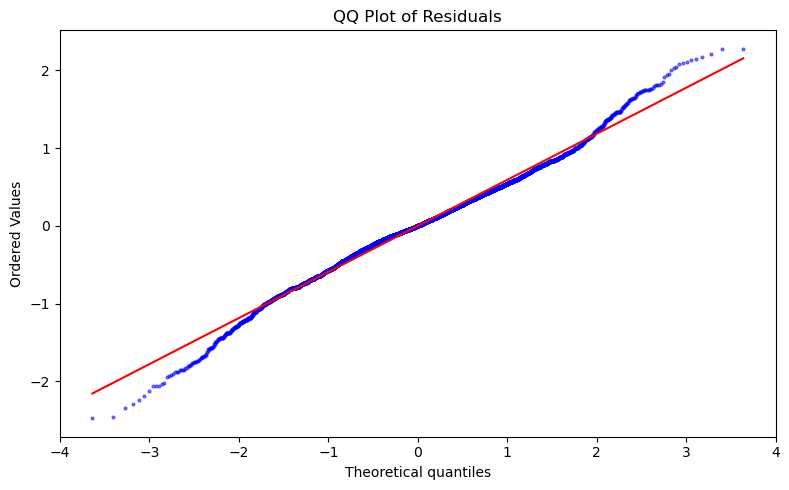

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
stats.probplot(m4.resid, dist="norm", plot=ax)
ax.get_lines()[0].set(color='blue', markersize=2, alpha=0.5)
ax.get_lines()[1].set(color='red')
ax.set_title("QQ Plot of Residuals")
plt.tight_layout()
plt.show()

with the data size we have (n is large), so we can even just cite CLT for normality of residuals. Therefore, the slight tail deviation isnt a concern.

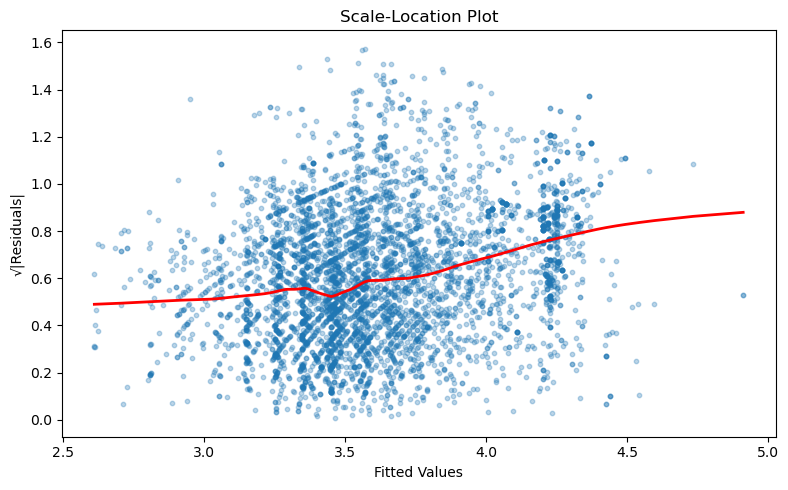

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(m4.fittedvalues, np.sqrt(np.abs(m4.resid)), alpha=0.3, s=10)
ax.set_xlabel("Fitted Values")
ax.set_ylabel("√|Residuals|")
ax.set_title("Scale-Location Plot")

# add a smoothed line to see the trend
from statsmodels.nonparametric.smoothers_lowess import lowess
smoothed = lowess(np.sqrt(np.abs(m4.resid)), m4.fittedvalues, frac=0.3)
ax.plot(smoothed[:, 0], smoothed[:, 1], color='red', linewidth=2)

plt.tight_layout()
plt.show()


## Scale-Location Plot

The smoothed red line shows a gentle upward slope, confirming mild heteroscedasticity. consistent with the residuals vs fitted plot 
justifies use of robust standard errors. 

## Quick Summary for Diagnostics


Model diagnostics confirm that linearity and approximate normality assumptions are reasonably met. Mild heteroscedasticity is present, justifying the use of 
robust standard errors. No observations are severely influential, and with n = 5056, HC2 is an appropriate and sufficient choice for robust standard error 
estimation given its asymptotic equivalence to HC3 at large sample sizes.

In [19]:
# Create interaction flag
new_products['is_fragrance_or_hair'] = new_products['primary_category'].isin(['Fragrance', 'Hair']).astype(int)

# Model 5
m5 = smf.ols(
    """log_price ~ C(primary_category, Treatment('Skincare'))
                + sephora_exclusive + limited_edition + online_only + new
                + size_ml + size_count
                + has_retinol + has_niacinamide + has_hyaluronic
                + has_vitamin_c + has_aha_bha + has_peptides
                + has_spf + has_fragrance + has_ceramides + has_vitamin_e
                + has_fragrance:is_fragrance_or_hair""",
    data=new_products
).fit(cov_type="HC2")

print(m5.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                     87.45
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        01:26:59   Log-Likelihood:                -4531.7
No. Observations:                5056   AIC:                             9109.
Df Residuals:                    5033   BIC:                             9260.
Df Model:                          22                                         
Covariance Type:                  HC2                                         
                                                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

In [20]:
# Show just the interaction related coefficients
params = m5.params
pvalues = m5.pvalues

terms = ['has_fragrance', 'is_fragrance_or_hair', 'has_fragrance:is_fragrance_or_hair']
for term in terms:
    if term in params:
        print(f"{term}: coef={params[term]:.4f}, p={pvalues[term]:.4f}")

has_fragrance: coef=0.0526, p=0.0337
has_fragrance:is_fragrance_or_hair: coef=0.2646, p=0.0000


In [21]:
#from the p val m5 (with interaction is significant, the code below confirms that/checks for taht)

from statsmodels.stats.anova import anova_lm
print("M4 vs M5 — Does the interaction add significant explanatory power?")
print(anova_lm(m4, m5))

M4 vs M5 — Does the interaction add significant explanatory power?
   df_resid          ssr  df_diff    ss_diff          F        Pr(>F)
0    5034.0  1788.556669      0.0        NaN        NaN           NaN
1    5033.0  1777.677272      1.0  10.879397  30.801995  3.003784e-08


## M4 vs M5 F-test

The F-test comparing M4 and M5 is highly significant (F=30.80, p<0.001)this justifes that the has_fragrance × is_fragrance_or_hair interaction term adds meaningful explanatory power. M5 is selected as the final model.

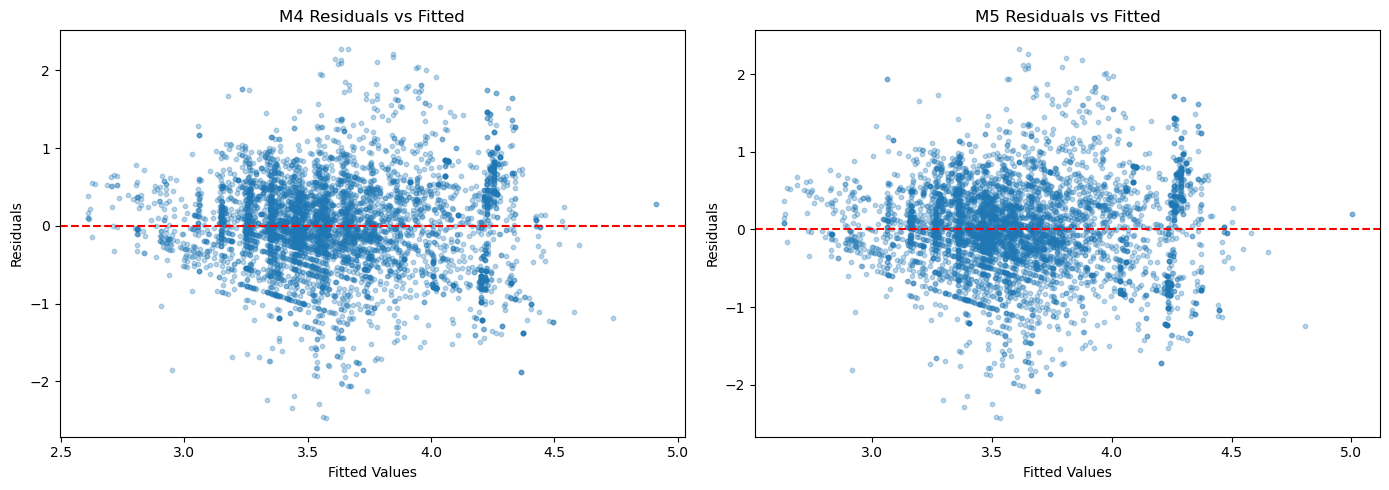

In [23]:
#I tried one diagnostic plot with m5 model to see if the results are consistent 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# M4
axes[0].scatter(m4.fittedvalues, m4.resid, alpha=0.3, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("M4 Residuals vs Fitted")

# M5
axes[1].scatter(m5.fittedvalues, m5.resid, alpha=0.3, s=10)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel("Fitted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("M5 Residuals vs Fitted")

plt.tight_layout()
plt.show()

In [25]:
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor
y5, X5 = dmatrices(
    """log_price ~ C(primary_category, Treatment('Skincare'))
                + sephora_exclusive + limited_edition + online_only + new
                + size_ml + size_count
                + has_retinol + has_niacinamide + has_hyaluronic
                + has_vitamin_c + has_aha_bha + has_peptides
                + has_spf + has_fragrance + has_ceramides + has_vitamin_e
                + has_fragrance:is_fragrance_or_hair""",
    data=new_products,
    return_type="dataframe"
)

X5_vif = X5.drop(columns=["Intercept"])

vif_m5 = pd.DataFrame()
vif_m5["feature"] = X5_vif.columns
vif_m5["VIF"] = [variance_inflation_factor(X5_vif.values, i) 
                 for i in range(X5_vif.shape[1])]

vif_m5.sort_values("VIF", ascending=False).style \
    .format({"VIF": "{:.2f}"}) \
    .background_gradient(subset=["VIF"], cmap="RdYlGn_r") \
    .set_caption("M5 Variance Inflation Factors") \
    .hide(axis="index")

feature,VIF
has_fragrance:is_fragrance_or_hair,9.19
"C(primary_category, Treatment('Skincare'))[T.Hair]",5.87
"C(primary_category, Treatment('Skincare'))[T.Fragrance]",3.69
has_fragrance,3.49
size_ml,2.55
has_spf,2.09
"C(primary_category, Treatment('Skincare'))[T.Makeup]",2.01
has_aha_bha,1.89
has_vitamin_e,1.68
has_hyaluronic,1.56


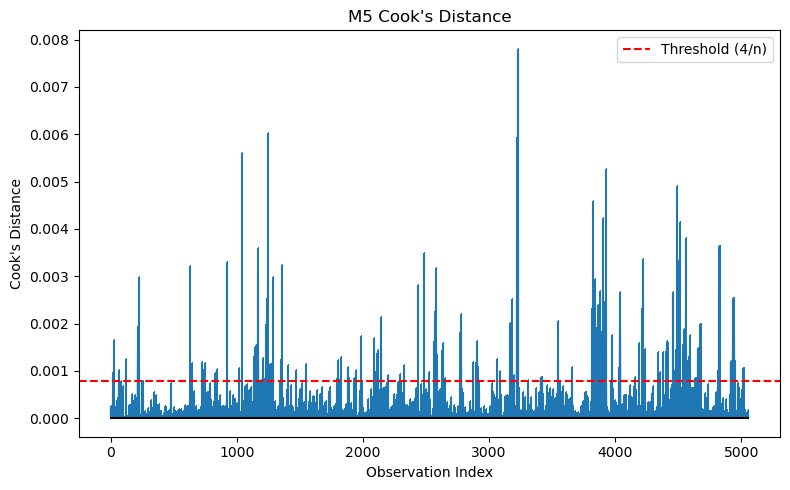

Max Cook's Distance: 0.0078
Observations above threshold: 280


In [26]:
influence_m5 = OLSInfluence(m5)
cooks_d_m5 = influence_m5.cooks_distance[0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.stem(range(len(cooks_d_m5)), cooks_d_m5, markerfmt=",", linefmt="C0-", basefmt="k-")
ax.axhline(4/len(cooks_d_m5), color='red', linestyle='--', label="Threshold (4/n)")
ax.set_xlabel("Observation Index")
ax.set_ylabel("Cook's Distance")
ax.set_title("M5 Cook's Distance")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Max Cook's Distance: {cooks_d_m5.max():.4f}")
print(f"Observations above threshold: {(cooks_d_m5 > 4/len(cooks_d_m5)).sum()}")

The cooks distance is similar to m4 and m5 

In [13]:
cat = "C(primary_category, Treatment('Skincare'))"

m1 = smf.ols(
    f"log_price ~ {cat}",
    data=new_products
).fit(cov_type="HC2")

m2 = smf.ols(
    f"""log_price ~ {cat}
        + sephora_exclusive + limited_edition + online_only + new
        + out_of_stock""",
    data=new_products
).fit(cov_type="HC2")

m3 = smf.ols(
    f"""log_price ~ {cat}
        + sephora_exclusive + limited_edition + online_only + new
        + out_of_stock
        + size_ml + size_count""",
    data=new_products
).fit(cov_type="HC2")

m4 = smf.ols(
    f"""log_price ~ {cat}
        + sephora_exclusive + limited_edition + online_only + new
        + out_of_stock
        + size_ml + size_count
        + has_retinol + has_niacinamide + has_hyaluronic
        + has_vitamin_c + has_aha_bha + has_peptides
        + has_spf + has_fragrance + has_ceramides + has_vitamin_e""",
    data=new_products
).fit(cov_type="HC2")

new_products["is_fragrance_or_hair"] = new_products["primary_category"].isin(["Fragrance", "Hair"]).astype(int)

m5 = smf.ols(
    f"""log_price ~ {cat}
        + sephora_exclusive + limited_edition + online_only + new
        + out_of_stock
        + size_ml + size_count
        + has_retinol + has_niacinamide + has_hyaluronic
        + has_vitamin_c + has_aha_bha + has_peptides
        + has_spf + has_fragrance + has_ceramides + has_vitamin_e
        + has_fragrance:is_fragrance_or_hair""",
    data=new_products
).fit(cov_type="HC2")

m6 = smf.ols(
    f"""log_price ~ {cat}
        + sephora_exclusive + limited_edition + online_only + new
        + out_of_stock
        + size_ml + size_count
        + has_retinol + has_niacinamide + has_hyaluronic
        + has_vitamin_c + has_aha_bha + has_peptides
        + has_spf + has_fragrance + has_ceramides + has_vitamin_e
        + has_fragrance:is_fragrance_or_hair
        + size_ml:{cat}""",
    data=new_products
).fit(cov_type="HC2")

In [ ]:
from statsmodels.stats.anova import anova_lm
import pandas as pd

comparisons = [
    ("m1 vs m2", m1, m2),
    ("m2 vs m3", m2, m3),
    ("m3 vs m4", m3, m4),
    ("m4 vs m5", m4, m5),
    ("m5 vs m6", m5, m6),
]

rows = []

for name, m_small, m_big in comparisons:
    a = anova_lm(m_small, m_big)
    row = a.iloc[1]  # second row = comparison
    
    rows.append({
        "Comparison": name,
        "df_diff": row["df_diff"],
        "ss_diff": row["ss_diff"],
        "F": row["F"],
        "p-value": row["Pr(>F)"]
    })

anova_full = pd.DataFrame(rows)
print(anova_full)


  Comparison  df_diff     ss_diff          F       p-value
0   m1 vs m2      5.0   58.393180  31.158472  2.423438e-31
1   m2 vs m3      2.0    4.632550   6.192517  2.060256e-03
2   m3 vs m4     10.0  105.062648  29.686042  3.862725e-56
3   m4 vs m5      1.0   10.994898  31.253446  2.383852e-08
4   m5 vs m6      5.0    1.296950   0.737134  5.955354e-01


Everything upto m5 keeps improving the models fit except m6. It only adds complexity, so the best model is 
**MODEL 5**